#Generates local radial density and compressibility profiles from spherical shells chunks measurements of a single sphere

In [70]:
import numpy as np
#import pandas as pd
from scipy import integrate
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update(mpl.rcParamsDefault)

import matplotlib
#matplotlib.matplotlib_fname ()
plt.style.use('tableau-colorblind10')

# plt.style.use("figures/fig.mplstyle")

In [71]:
writedata=False
savefigs=False
savedata=False
runits_mw=False
Attractive=True # Use if we are considering solutes with attration to water and set D0 parameter
Pderiv=False
LR=True

In [72]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

In [73]:
def smooth_right(y, box_pts):
    box = np.ones(box_pts) / box_pts
    y_smooth = np.convolve(y, box, mode='full')[:len(y)]
    return y_smooth


In [74]:
user = "phxnw"
overleafpath = f"/Users/{user}/Dropbox/Apps/Overleaf/Hydrophobic attraction between solutes/Figures/"
if(Attractive):
    if(LR):
        opDir=f"/Users/{user}/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/LR_pot/Additive/FigsData/"
        ipDir=f"/Users/{user}/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/LR_pot/Additive/Data/"
    else:
        opDir=f"/Users/{user}/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/Figs/"
        ipDir=f"/Users/{user}/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/Data/"
else:
    opDir=f"/Users/{user}/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Hard_solute/Figs/"
    ipDir=f"/Users/{user}/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Hard_solute/Data/"

In [75]:
if(Attractive):
   
    
    D0vals=[0.01,0.6,0.8,1.0,1.2,1.4] # Rs=10
    D0vals=[0.01,0.6,0.8,1.0] # Rs=5
    D0vals=[0.01,0.2,0.4,0.6] # Rs=3
    D0vals=[0.01,0.2] # Rs=2
    Pressures=[0]
    Tvals=[300]
    #Tvals=[300,350,426]
    Rsvals=[2]
else:
    D0vals=[1.0]
    Tvals=[300]
    #Rsvals=[7,14,25,50]
    #Rsvals=[7]
    #Rsvals=[10]
    Rsvals=[15]
    #Rsvals=[20]
    if Rsvals==[20]:
        Pressures=[0,200,500,1000,2000,3000]
    if Rsvals==[15]:
        #Pressures=[0,200,500,1000,2000,3000]
        Pressures=[0,200,500,1000,1500,2000]
    if Rsvals==[10]:    
        Pressures=[0,200,500,1000,1500,2000,3000,4000]
    if Rsvals==[7]:    
        Pressures=[0,500,1000,2000]

In [76]:
kB=1.38E-23
sig_mw=2.3925

In [77]:
rvalslist=[]
denproflist=[]
chiproflist=[]
Rslist=[]
Plist=[]
Tlist=[]
D0list=[]
molrholist=[]
chiblist=[]

In [78]:
def bulkparams(T,P):
#default L and dl
    dl=0.15
    L=60
    if T==426:
        if P==0:
            molrho=3.205e+28      # Known from bulk simulation
            chi_b=2.54E-10  
        if P==500:
            molrho=3.244e+28     
            chi_b=2.174E-10
        if P==750:
            molrho=3.261e+28    
            chi_b=2.2047E-10
        if P==1000:
            molrho=3.277e+28      
            chi_b=1.920e-10  
        if P==1500:
            molrho=3.308e+28     
            chi_b=1.726e-10     
    if T==300:
        if P==0:
            molrho=3.333e+28      
            chi_b=1.967e-10 
        if P==100:
            molrho=3.340e+28      
            chi_b=1.9201E-10
        if P==200:
            molrho=3.346e+28     
            chi_b=1.8921E-10
        if P==300:
            molrho=3.3527e28 
            chi_b=1.843E-10
            mu_ex=1.617    
        if P==500:
            molrho=3.365e+28     
            chi_b=1.75901E-10 
        if P==750:
            molrho=3.379e+28      
            chi_b=1.67551E-10 
        if P==1000:
            molrho=3.393e+28     
            chi_b=1.587E-10
        if P==1500:
            molrho=3.419e+28      
            chi_b=1.456E-10                
        if P==2000:
            molrho=3.444e+28      
            chi_b=1.343E-10
        if P==3000:
            molrho=3.4875e+28      
            chi_b=1.168E-10
        if P==4000:
            molrho=3.526e+28      
            chi_b=1.030e-10 
        if P==5000:
            molrho=3.561e+28      
            chi_b=9.272e-11
    if T==325:
        if P==0:
            molrho=3.314e+28      
            chi_b=1.991e-10
    if T==350:
        if P==0:
            molrho=3.291e+28      
            chi_b=2.072e-10
    if T==375:
        if P==0:
            molrho=3.265e+28      
            chi_b=2.180e-10
    if T==400:
        if P==0:
            molrho=3.237e+28      
            chi_b=2.350e-10
    if T==425:
        if P==0:
            molrho=3.207e+28      
            chi_b=2.536e-10            
# Alterations to defaults
    if P==0 and Rs==14 and T==300:
        L=80
        dl=0.3
    if P==0 and Rs==25 and T==300:
        L=80
        dl=0.4
    if P==500 and Rs==25 and T==300:
        L=80
        dl=0.25
    if P==1000 and Rs==25 and T==300:
        L=80
        dl=0.25
    if P==0 and Rs==50 and T==300:
        L=120
        dl=0.4
    return L,dl,molrho,chi_b

In [79]:
for T in Tvals:
    for D0 in D0vals:
        for Rs in Rsvals:
            for P in Pressures:  
                L,dl,molrho,chi_b=bulkparams(T,P)
                print ('Rs=',Rs,'T=',T,'P=',P,'D0=',D0,'L=',L,'dl=',dl,'molrho=',molrho,'chi_b=',chi_b)
                opfile = f"{ipDir}op.T{T}.P{P}.D0{D0}.Rs{Rs}.csv"
                chunksfile = f"{ipDir}shells-T{T}-P{P}-dr{dl}-D0{D0}-Rs{Rs}.profile"
             #   chunksfile = ipDir+"shells-T{}-P{}-dr{}-D0{D0:.2f}-Rs{}.profile".format(T,P,dl,Rs)
                print('opfile=',opfile)
                print('chunksfile=',chunksfile)    
                Plist.append(P)
                Tlist.append(T)
                Rslist.append(Rs)
                D0list.append(D0)
                molrholist.append(molrho)
                chiblist.append(chi_b)
                
                with open(opfile) as f:
                    next(f)
                    samples=np.loadtxt(f,delimiter=',')
                Vs=np.array(samples[:,5])
                L=np.floor(((Vs.mean())**0.333)/sig_mw)
                Lhsig=L/2
                av_V=Vs.mean()*1e-30
            
                with open(chunksfile) as f:     
                    for line in f:
                        elements = line.split()
                        len_ele=len(elements)
                        if(len_ele==3):
                            nent=int(elements[1])
                        if len(elements)==5:
                            prof = np.loadtxt(f,max_rows = nent)
                prof=prof[:-1,:] # last line is weird
                rvals=prof[:,1]
                rvalslist.append(rvals)
                Nav=prof[:,2]
                rhoav=Nav/(4*np.pi*(rvals**2)*dl*1e-30)
                denproflist.append(rhoav)
                
                NVav=prof[:,4]
                rhoVav=NVav/(4*np.pi*(rvals**2)*dl) # Note no factor of 1e-30 needed here because the V that Lammps uses is also missing this factor
                chiprof=-(rhoVav-rhoav*av_V)/(molrho*kB*T*chi_b)
                chiproflist.append(chiprof)
                
                if(writedata):
                    opcorr=open(opDir+"profden_dl{}_Rs_{}_T{}_P{}_D0{}".format(dl,Rs,T,P,D0),"w")
                    points=[rvals/sig_mw,rhoav]
                    for x in zip(*points):
                        opcorr.write("{0}\t{1}\n".format(*x))
                    opcorr.close()
            
                    opcorr=open(opDir+"profcovar_dl{}_Rs_{}_T{}_P{}".format(dl,Rs,T,P),"w")
                    points=[rvals/sig_mw,chiprof]    
                    for x in zip(*points):
                        opcorr.write("{0}\t{1}\n".format(*x))
                    opcorr.close()
    print('Read',len(denproflist),'datasets')


Rs= 2 T= 300 P= 0 D0= 0.01 L= 60 dl= 0.15 molrho= 3.333e+28 chi_b= 1.967e-10
opfile= /Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/LR_pot/Additive/Data/op.T300.P0.D00.01.Rs2.csv
chunksfile= /Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/LR_pot/Additive/Data/shells-T300-P0-dr0.15-D00.01-Rs2.profile
Rs= 2 T= 300 P= 0 D0= 0.2 L= 60 dl= 0.15 molrho= 3.333e+28 chi_b= 1.967e-10
opfile= /Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/LR_pot/Additive/Data/op.T300.P0.D00.2.Rs2.csv
chunksfile= /Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_spherechunks/Attractive_solute/LR_pot/Additive/Data/shells-T300-P0-dr0.15-D00.2-Rs2.profile
Read 2 datasets


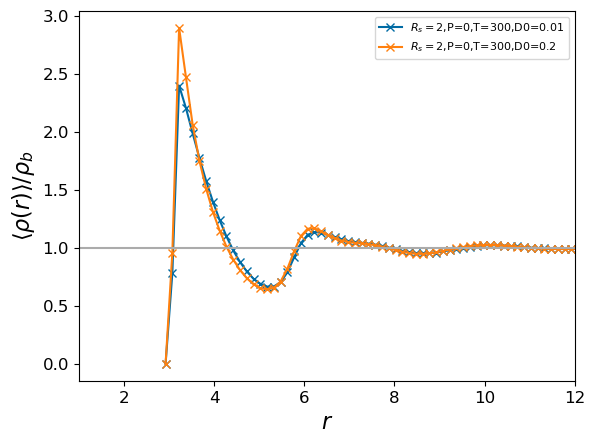

In [80]:
#Write out density profiles


plt.xlim(Rs-1,Lhsig*sig_mw+15)
plt.xlim(Rs-1,Rs+10)
#plt.ylim(0,3.00)
#plt.yticks(np.arange(0, 0.101, 0.25))
#plt.xticks(np.arange(0, Lhsig, 1.0))
plt.xticks(fontsize= 12)
plt.yticks(fontsize= 12)
plt.ylabel(r"$\langle\rho(r)\rangle/\rho_b$",fontsize=16)
for i in range(0,len(denproflist)):
    x=rvalslist[i]
    y=denproflist[i]
    xn=x[y!=0]
    yn=y[y!=0]
    if(runits_mw):
        plt.plot(xn/sig_mw,yn/molrholist[i],marker='x',label=r"$R_s/\sigma_{{mw}}={:.2f}$,P={},T={},D0={}".format(Rslist[i]/sig_mw,Plist[i],Tlist[i],D0list[i]))
    else:
        plt.plot(xn,yn/molrholist[i],marker='x',label=r"$R_s={}$,P={},T={},D0={}".format(Rslist[i],Plist[i],Tlist[i],D0list[i]))
if(runits_mw):
    plt.xlabel(r"$r/\sigma_{{mw}}$",fontsize=16)
    plt.plot(rvals/sig_mw,np.ones_like(rhoav))
else:
    plt.xlabel(r"$r$",fontsize=16)
    plt.plot(rvals,np.ones_like(rhoav))

plt.legend(loc="best",fontsize= 8)
if(savefigs):
    path=opDir+"sph_densprof_comparison.pdf"
    plt.savefig(path,format="pdf")

plt.show()




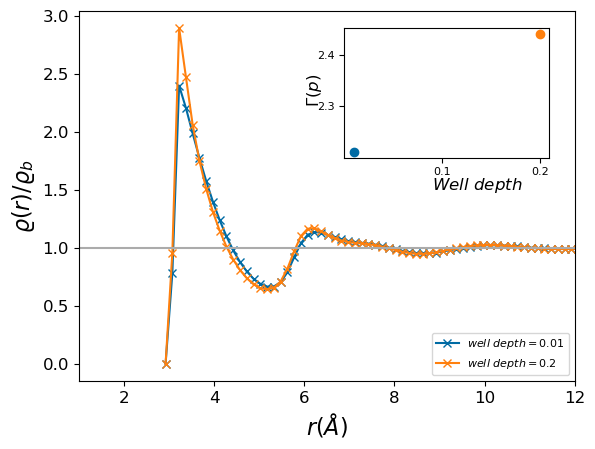

In [81]:
#Write out density profiles with adsorption inset

fig, ax1 = plt.subplots()

plt.xlim(Rs-1,Lhsig*sig_mw+15)
plt.xlim(Rs-1,Rs+10)
#plt.ylim(0,2.001)
#plt.xticks(np.arange(0, Lhsig, 1.0))
plt.yticks(np.arange(0, 5.01, 0.5))
plt.xticks(fontsize= 12)
plt.yticks(fontsize= 12)
plt.ylabel(r"$\varrho(r)/\varrho_b$",fontsize=16)
for i in range(0,len(denproflist)):
    x=rvalslist[i]
    y=denproflist[i]
    xn=x[y!=0]
    yn=y[y!=0]
    if(runits_mw):
        plt.plot(xn/sig_mw,yn/molrholist[i],marker='x',label=r"$R_s/\sigma_{{mw}}={:.2f}$,p={},T={},D0={}".format(Rslist[i]/sig_mw,Plist[i],Tlist[i],D0list[i]))
    else:
        #plt.plot(xn,yn/molrholist[i],marker='x',label=r"$R_s={}$,P={},T={},D0={}".format(Rslist[i],Plist[i],Tlist[i],D0list[i]))
        plt.plot(xn,yn/molrholist[i],marker='x',label=r"$well~depth={}$".format(D0list[i]))
        if(savedata):
            np.savetxt(f"figures/Fig-chi-rho/rho_P{Plist[i]}.txt", list(zip(xn,yn/molrholist[i])))
if(runits_mw):
    plt.xlabel(r"$r/\sigma_{{mw}}$",fontsize=16)
    plt.plot(rvals/sig_mw,np.ones_like(rhoav))
else:
    plt.xlabel(r"$r (\AA)$",fontsize=16)
    plt.plot(rvals,np.ones_like(rhoav))
#plt.text(14.2, 1.85, '(a)', fontsize = 14)
plt.legend(loc="lower right",fontsize= 8)


#Plot adsorption integral as inset

# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.54, 0.575, 0.32, 0.27]
ax2 = fig.add_axes([left, bottom, width, height])


plt.xticks(fontsize= 8)
plt.yticks(fontsize= 8)
#plt.ylim(-30,40)
#plt.xlim(0,2500)
#plt.yticks(np.arange(-2e18, 2.01e18, 1e18))
plt.xlabel(r"$Well~depth$",fontsize=12)
plt.ylabel(r"$\Gamma(p)$",fontsize=12)

#plt.title(r"Adsorption as a function of $D0$, $R_s$={}".format(Rs),fontsize=16)

adsorptions = []
for i in range(0,len(denproflist)):
    denprof=denproflist[i]
    molrho=molrholist[i]
    rvals=rvalslist[i]
    startint= np.where(np.array(denprof) != 0)[0]
    denstrip=denprof[startint[0]:]
    rvalstrip=rvals[startint[0]:]
    adsorb=integrate.trapezoid(4*np.pi*((1e-10*rvalstrip)**2)*(denstrip-molrho),rvalstrip*1e-10)
    ax2.plot(D0list[i],adsorb,marker='o')
    adsorptions.append(adsorb)

if(savedata):
    np.savetxt(f"figures/Fig-chi-rho/adsorptions.txt", list(zip(D0list,adsorptions)))

ax2.xaxis.set_label_coords(0.65, -0.14)
ax2.yaxis.set_label_coords(-0.1, 0.52)
#plt.legend(loc="lower right",fontsize= 8)
#ax2.plot(range(6)[::-1], color='blue')
if(savefigs):
    path=overleafpath+"denprofs_variousD0_T{}_Rs{}.pdf".format(T,Rs)
    plt.savefig(path,format="pdf")
plt.show()




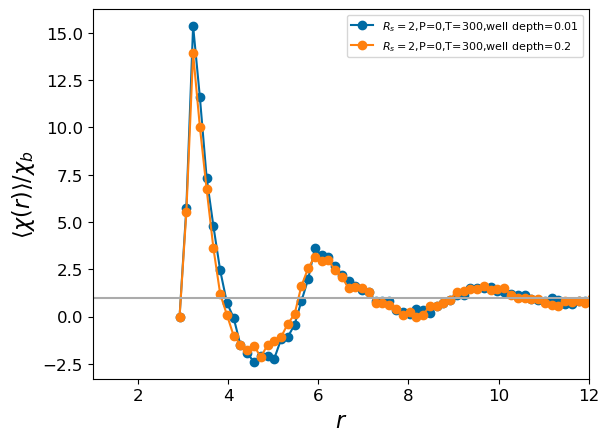

In [82]:
#Write out compressibility profiles
plt.xticks(fontsize= 12)
plt.yticks(fontsize= 12)

plt.xlim(Rs-1,Rs+10)
plt.ylabel(r"$\langle\chi(r)\rangle/\chi_b$",fontsize=16)
for i in range(0,len(denproflist)):
    x=rvalslist[i]
    y=chiproflist[i]
    xn=x[y!=0]
    yn=y[y!=0]
    if(runits_mw):
        plt.plot(xn/sig_mw,yn,marker='o',label=r"$R_s/\sigma_{{mw}}={:.2f}$,P={},T={},well depth={}".format(Rslist[i]/sig_mw,Plist[i],Tlist[i],D0list[i]))
    else:
        plt.plot(xn,yn,marker='o',label=r"$R_s={}$,P={},T={},well depth={}".format(Rslist[i],Plist[i],Tlist[i],D0list[i]))
if(runits_mw):
    plt.xlabel(r"$r/\sigma_{{mw}}$",fontsize=16)
    plt.plot(rvals/sig_mw,np.ones_like(chiprof[:len(rvals)]))
else:
    plt.xlabel(r"$r$",fontsize=16)
    plt.plot(rvals,np.ones_like(chiprof[:len(rvals)]))

plt.legend(loc="best",fontsize= 8)
if(savefigs):
    path=opDir+"sph_chiprofs_comparison.pdf"
    plt.savefig(path,format="pdf")
plt.show()


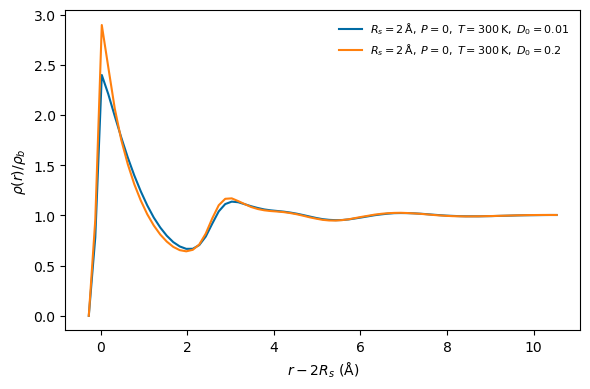

In [83]:
# ===== Density profiles: rho(r)/rho_b =====

from pathlib import Path
import numpy as np

savedata = True

Path(opDir).mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))

for i in range(len(denproflist)):
    x = np.asarray(rvalslist[i])
    y = np.asarray(denproflist[i])

    mask = (y != 0)
    xn = x[mask]
    yn = y[mask]

    # shift x-axis by Rs
    xshift = xn - (1.0 * Rslist[i]+sig_mw/2)

    rho_red = yn / molrholist[i]

    ax.plot(
        xshift,
        rho_red,
        label=rf"$R_s={Rslist[i]}\,\mathrm{{\AA}},\;P={Plist[i]},\;T={Tlist[i]}\,\mathrm{{K}},\;D_0={D0list[i]}$"
    )

    if savedata:
        tag = f"T{Tlist[i]}_P{Plist[i]}_Rs{Rslist[i]}_D0{D0list[i]}"
        outfile = Path(opDir) / f"rho_profile_{tag}.dat"

        np.savetxt(
            outfile,
            np.column_stack([xshift, rho_red]),
            header=(
                "r_minus_2Rs_Angstrom   rho_over_rhob\n"
                f"T = {Tlist[i]} K\n"
                f"P = {Plist[i]}\n"
                f"Rs = {Rslist[i]} Angstrom\n"
                f"D0 = {D0list[i]}\n"
                f"rho_b = {molrholist[i]:.8e}"
            )
        )

ax.set_xlabel(r"$r-2R_s$ ($\mathrm{\AA}$)")
ax.set_ylabel(r"$\rho(r)/\rho_b$")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

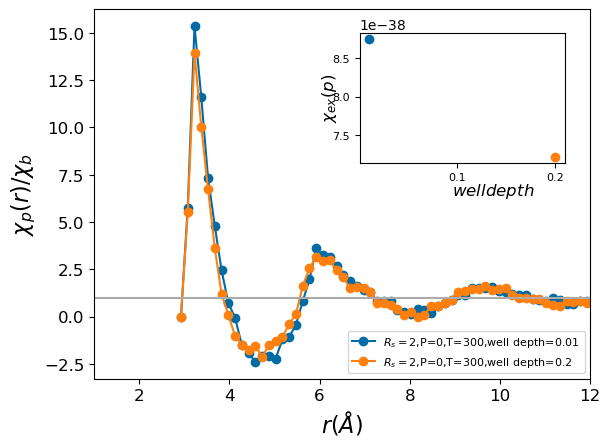

In [84]:
#Write out compressibility profiles with excess compressibility in inset

fig, ax1 = plt.subplots()
plt.style.use('tableau-colorblind10')
plt.xticks(fontsize= 12)
plt.yticks(fontsize= 12)
#plt.ylim(-10,40)
plt.xlim(Rs-1,Rs+10)
plt.ylabel(r"$\chi_p(r)/\chi_b$",fontsize=16)
for i in range(0,len(denproflist)):
    x=rvalslist[i]
    y=chiproflist[i]
    xn=x[y!=0]
    yn=y[y!=0]
    if(runits_mw):
        plt.plot(xn/sig_mw,yn,marker='o',label=r"$R_s/\sigma_{{mw}}={:.2f}$,p={},T={},well depth={}".format(Rslist[i]/sig_mw,Plist[i],Tlist[i],D0list[i]))
    else:
        plt.plot(xn,yn,marker='o',label=r"$R_s={}$,P={},T={},well depth={}".format(Rslist[i],Plist[i],Tlist[i],D0list[i]))
        #plt.plot(xn,yn,marker='x',label=r"$well depth={}$".format(D0list[i]))
if(runits_mw):
    plt.xlabel(r"$r/\sigma_{{mw}}$",fontsize=16)
    plt.plot(rvals/sig_mw,np.ones_like(chiprof[:len(rvals)]))
else:

    plt.xlabel(r"$r(\AA)$",fontsize=16)
    plt.plot(rvals,np.ones_like(chiprof[:len(rvals)]))

plt.legend(loc="lower right",fontsize= 8)
#plt.text(14.2, 36, '(b)', fontsize = 14)


# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.54, 0.56, 0.32, 0.27]
ax2 = fig.add_axes([left, bottom, width, height])

plt.xticks(fontsize= 8)
plt.yticks(fontsize= 8)
#plt.ylim(0,0.6e-35)
plt.xlabel(r"$well depth$",fontsize=12)
plt.ylabel(r"$\chi_{ex}(p)$",fontsize=12)

excomps =[]
for i in range(0,len(denproflist)):
    chiprof=chiproflist[i]
    chi_b=chiblist[i]
    rvals=rvalslist[i]
    startint= np.where(np.array(chiprof) != 0)[0]
    stopint= np.where(np.array(rvals)>Rs+8)[0]
                      
    chistrip=chiprof[startint[0]:stopint[0]]
    rvalstrip=rvals[startint[0]:stopint[0]]
    excomp=integrate.trapezoid(4*np.pi*((1e-10*rvalstrip)**2)*(chistrip*chi_b-chi_b),rvalstrip*1e-10)
    ax2.plot(D0list[i],excomp,marker='o',label=r"$R={:.0f}$,p={},T={},well depth={}".format(Rslist[i],Plist[i],Tlist[i],D0list[i]))
    excomps.append(excomp)

#plt.legend(loc="best",fontsize= 8)
ax2.xaxis.set_label_coords(0.65, -0.14)
ax2.yaxis.set_label_coords(-0.1, 0.5)
if(savefigs):
    path=overleafpath+"chiprofs_variousP_T{}_Rs{}.pdf".format(T,Rs)
    plt.savefig(path,format="pdf")

plt.show()





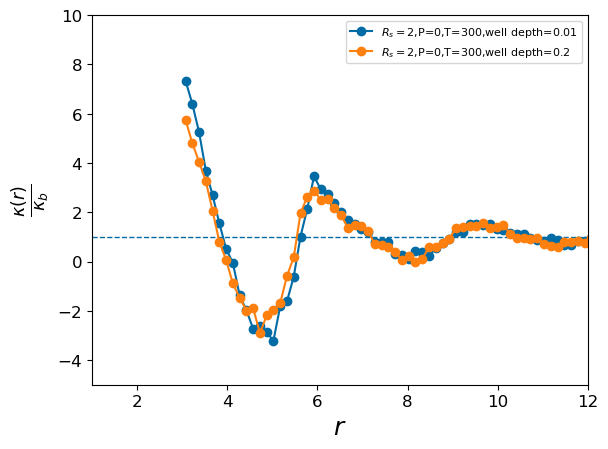

In [85]:
plt.style.use('tableau-colorblind10')
fig, ax1 = plt.subplots()

ax1.set_ylim(-5,10)
ax1.set_xlim(Rs-1, Rs+10)
ax1.tick_params(labelsize=12)
ax1.set_xlabel(r"$r$", fontsize=18)
ax1.set_ylabel(r"$\frac{\kappa(r)}{\kappa_b}$", fontsize=18)

ax1.axhline(1.0, linestyle="--", linewidth=1)

excomps = []

for i in range(len(denproflist)):
    chiprof = chiproflist[i]
    chi_b   = chiblist[i]
    rvals   = rvalslist[i]

    startint = np.where(np.array(chiprof) != 0)[0]
    i0 = startint[0] + 1

    chistrip  = chiprof[i0:]
    rvalstrip = rvals[i0:]

    denprof = denproflist[i]
    molrho  = molrholist[i]
    denstrip = denprof[i0:]

    ratio = chistrip * chi_b / denstrip
    rationorm = (ratio / chi_b) * molrho
    ratio2norm = rationorm * molrho/ denstrip 
    rationorm=smooth_right(rationorm,1)

    ax1.plot(
        rvalstrip, rationorm, marker='o',
        label=rf"$R_s={Rslist[i]:.0f}$,P={Plist[i]},T={Tlist[i]},well depth={D0list[i]}"
    )

    excomp = integrate.trapezoid(
        4*np.pi*((1e-10*rvalstrip)**2)*(ratio - chi_b/molrho),
        1e-10*rvalstrip
    )
    excomps.append(excomp)

ax1.legend(loc="best", fontsize=8)

# These are in unitless percentages of the figure size. (0,0 is bottom left)
#print(excomps)
#left, bottom, width, height = [0.44, 0.44, 0.42, 0.37]
#ax2 = fig.add_axes([left, bottom, width, height])
#plt.xticks(fontsize= 8)
#plt.yticks(fontsize= 8)
#plt.ylim(0,2.2e-35)
#plt.xlabel(r"$D0$",fontsize=12)
#plt.ylabel(r"$\int 4\pi r^2[\chi(r)/\rho(r)-\chi_b/\rho_b]dr$",fontsize=10)
#ax2.plot(D0list,excomps,marker='o',label=r"$R={:.0f}$,p={},T={},well depth={}".format(Rslist[i],Plist[i],Tlist[i],D0list[i]))
#ax2.xaxis.set_label_coords(0.65, -0.08)
#ax2.yaxis.set_label_coords(-0.1, 0.5)
#plt.legend(loc="best",fontsize= 6)

plt.show()


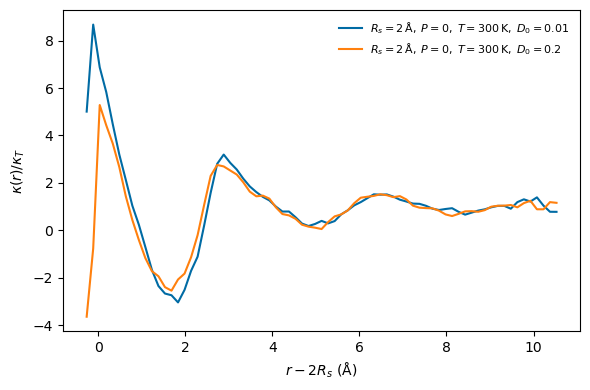

In [86]:
# ===== Local compressibility: kappa(r)/kappa_T =====

from pathlib import Path
import numpy as np

savedata = True

Path(opDir).mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))

for i in range(len(chiproflist)):
    rvals = np.asarray(rvalslist[i])
    chiprof = np.asarray(chiproflist[i])
    denprof = np.asarray(denproflist[i])

    rho_b = molrholist[i]

    mask = (chiprof != 0) & (denprof != 0)
    rvalstrip = rvals[mask]

    # shift x-axis by Rs+sig_mw/2
    xshift = xn - (1.0 * Rslist[i]+sig_mw/2)

    # convert chi(r)/chi_b -> kappa(r)/kappa_T
    rationorm = smooth(chiprof[mask] * rho_b / denprof[mask],2)

    ax.plot(
        xshift,
        rationorm,
        label=rf"$R_s={Rslist[i]}\,\mathrm{{\AA}},\;P={Plist[i]},\;T={Tlist[i]}\,\mathrm{{K}},\;D_0={D0list[i]}$"
    )

    if savedata:
        tag = f"T{Tlist[i]}_P{Plist[i]}_Rs{Rslist[i]}_D0{D0list[i]}"
        outfile = Path(opDir) / f"kappa_profile_{tag}.dat"

        np.savetxt(
            outfile,
            np.column_stack([xshift, rationorm]),
            header=(
                "r_minus_2Rs_Angstrom   kappa_over_kappaT\n"
                f"T = {Tlist[i]} K\n"
                f"P = {Plist[i]}\n"
                f"Rs = {Rslist[i]} Angstrom\n"
                f"D0 = {D0list[i]}\n"
                f"rho_b = {molrholist[i]:.8e}\n"
                f"chi_b = {chiblist[i]:.8e}"
            )
        )

ax.set_xlabel(r"$r-2R_s$ ($\mathrm{\AA}$)")
ax.set_ylabel(r"$\kappa(r)/\kappa_T$")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()